# Limit contour: event list → excluded $(m_\text{DM}, \alpha_n)$ region

**Private.** Successor to `12_limit_atmos`, with the limit set by the public
[`optimum_interval`](https://github.com/tunnell/optimum_interval) package
instead of the $\langle N\rangle = 3$ rule, so observed candidate events are
handled without a background model.

## What this notebook does

1. **Input** — the `EVENTS` array of reconstructed kick momenta (here one
   random toy candidate). *Replacing this array with data is the only change
   needed to run the real analysis.*
2. **Halo** — standard-halo-model speed distribution at the top of the
   atmosphere (`luhdm.halo`).
3. **Attenuation** — every trajectory is slowed through the atmosphere by the
   energy-loss ODE (`luhdm.atmosphere`); the resulting detector-frame $f(v)$
   also carries the survival fraction.
4. **Cross section** — classical impulse from a finite-range Yukawa on the
   finite-size magnet; the projected $d\sigma/dq$ comes from inverting $K_1$
   (`luhdm.cross_section`).
5. **Rate** — $dR/dq = n_\text{DM}\int f(v)\,v\,(d\sigma/dq)\,dv$
   (`differential_rate_trapz`, defined in this notebook: it is the formula you
   tweak).
6. **Statistics** — at each $(m_\text{DM}, \alpha_n)$ grid point: expected
   counts $\mu$ and the normalized spectrum shape feed the optimum-interval
   **extremeness** (`luhdm.limits`, wrapping the package primitives). Because
   the spectrum shape itself depends on the coupling (finite range and
   attenuation), the limit is a **level set of the extremeness surface**, not a
   single $\mu$ solve.
7. **Flux sanity** — the expected number of particles passing within the
   threshold reach, $N_t = T\int n f(v)\,v\,\pi b_\text{max}^2(v)\,dv$, is
   recorded at every grid point. Since every above-threshold kick is such a
   transit, $\mu \le N_t$: the 95% region ($\mu \gtrsim 3$) automatically
   satisfies "at least one particle expected during the exposure" — shown
   explicitly below with and without the constraint.
8. **Outputs** — the exclusion figures and the machine-readable
   `limit_contour_data.npz` (grids, surfaces, contour polylines).


In [1]:
%matplotlib inline
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from luhdm import atmosphere, config, cross_section, halo, limits, units

# fiducials, as in 12_limit_atmos cell 18
LAMB = 3e-3                       # mediator range [m]
R_eff = config.R_EFF
Q_THRESH = config.Q_THRESH
T_TOTAL = 3600 * 24 * 7 * 2      # 2 weeks in seconds
CONFIDENCE = 0.95

def lamb_label(lamb_m):
    # mediator range in SI and natural units, for plot labels
    x = units.conv_m2pGeV(lamb_m)
    e = int(np.floor(np.log10(x)))
    si = f"{lamb_m * 1e3:.0f} mm" if lamb_m < 1 else f"{lamb_m:.0f} m"
    return rf"$\lambda$ = {si} = ${x / 10**e:.1f}\times10^{{{e}}}$ GeV$^{{-1}}$"


np.random.seed(20260702)         # luhdm samplers use legacy np.random
print(f"N_n = {config.N_NEUTRONS:.2e}   q_th = {Q_THRESH:.0f} GeV   "
      f"xi = {R_eff / LAMB:.3f}")

N_n = 2.51e+20   q_th = 8400 GeV   xi = 0.087


## Input: the event list

One candidate kick drawn at random just above threshold. **Replace this array
with the reconstructed kicks from data and rerun — nothing else changes.**


In [2]:
rng = np.random.default_rng(20260702)
EVENTS = 10 ** rng.uniform(np.log10(Q_THRESH), np.log10(3 * Q_THRESH), size=1)
print(f"observed kicks [GeV]: {np.round(EVENTS, 1)}")

observed kicks [GeV]: [12625.]


## Cross-section interpolant

One-time tabulation of the dimensionless $d\sigma/d\tilde q$ (now provided by
`luhdm.cross_section`, same call as before).


In [3]:
print("Computing dsigma_dq interpolant...")
interpolant = cross_section.make_dsigma_dq_interpolant(1e-25, R_eff, LAMB)
print("Done")

Computing dsigma_dq interpolant...


  0%|          | 0/1000 [00:00<?, ?it/s]

~/code/luhdm/luhdm/cross_section.py:302: IntegrationWarning: The maximum number of subdivisions (100) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result, _ = quad(integrand, 0, t_max, limit=100)
  0%|          | 2/1000 [00:00<01:01, 16.33it/s]

~/code/luhdm/luhdm/cross_section.py:302: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, _ = quad(integrand, 0, t_max, limit=100)
  0%|          | 4/1000 [00:00<01:00, 16.59it/s]

  1%|          | 6/1000 [00:00<00:55, 17.83it/s]

...

 93%|█████████▎| 929/1000 [00:30<00:00, 76.16it/s]

 94%|█████████▍| 940/1000 [00:30<00:00, 80.57it/s]

 95%|█████████▍| 949/1000 [00:30<00:00, 81.28it/s]

100%|██████████| 1000/1000 [00:30<00:00, 32.31it/s]

Done


## Differential rate — the physics to tweak

Same formula and notation as `12_limit_atmos` (`mu` is the DM mass in the
original notation); only the rate conversion constant moved to `luhdm.units`.


In [4]:
def differential_rate_trapz(qs, alpha_n, lamb, mu, R_eff, f_v_f, dsigma_interpolant):
    '''dR/dq via trapz (mu = m_DM in the original notation).'''
    alpha = alpha_n * config.N_NEUTRONS
    n_dm = halo.number_density_dm(mu)

    # Precompute f_vf on a fixed grid spanning all v_mins
    v_min_global = qs.min() / mu
    vs_global = np.geomspace(v_min_global, config.VESC, 500)
    f_vf_grid = f_v_f(vs_global)  # KDE evaluated once

    results = []
    for q in qs:
        v_min = q / mu
        mask = vs_global >= v_min
        vs = vs_global[mask]
        fvf = f_vf_grid[mask]
        integrand = n_dm * fvf * vs * cross_section.dsigma_dq(
            q, alpha, lamb, R_eff, vs, dsigma_interpolant)
        results.append(np.trapezoid(integrand, vs) * units.CONV2RATE)

    return np.maximum(np.array(results), 0)


v_i_samples = atmosphere.sample_shm(int(1e5))  # SHM at the top of the atmosphere


def expected_transits(alpha_n, mu, f_v_f):
    # expected flybys within the threshold reach during the exposure (mu = m_DM)
    alpha = alpha_n * config.N_NEUTRONS
    vs = np.geomspace(max(Q_THRESH / mu, 1e-8), config.VESC, 300)
    b = cross_section.impact_parameter_max(Q_THRESH, alpha, LAMB, R_eff, vs)
    n_m3 = 0.3 / mu * 1e6  # rho = 0.3 GeV/cm^3 -> 1/m^3
    return T_TOTAL * np.trapezoid(
        f_v_f(vs) * n_m3 * (vs * units.C_M_S) * np.pi * b**2, vs)

## Spectra

The attenuated $dR/dq$ for a few masses at fixed coupling (the analog of the
spectra figure in `12_limit_atmos`).


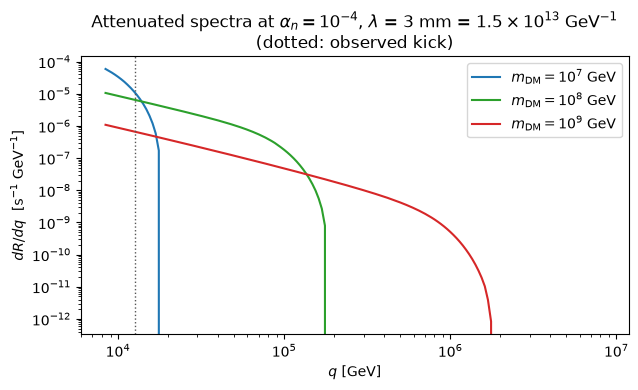

In [5]:
ALPHA_N_SHOW = 1e-4
qs_plot = np.geomspace(Q_THRESH, 1000 * Q_THRESH, 160)

fig, ax = plt.subplots(figsize=(6.5, 4))
for m, color in [(1e7, "#1f77b4"), (1e8, "#2ca02c"), (1e9, "#d62728")]:
    v_min = qs_plot.min() / m / 10
    v_f_samples = atmosphere.compute_v_f_distribution(
        ALPHA_N_SHOW, LAMB, m, v_i_samples, v_min=v_min, n_grid=80)
    f_v_f = atmosphere.compute_f_vf(v_f_samples, v_min)[0]
    ax.loglog(qs_plot,
              differential_rate_trapz(qs_plot, ALPHA_N_SHOW, LAMB, m, R_eff,
                                      f_v_f, interpolant),
              color=color, label=rf"$m_{{\rm DM}} = 10^{{{int(np.log10(m))}}}$ GeV")
for q_ev in EVENTS:
    ax.axvline(q_ev, color="#555555", lw=1, ls=":")
ax.set_xlabel(r"$q$ [GeV]")
ax.set_ylabel(r"$dR/dq$  [s$^{-1}$ GeV$^{-1}$]")
ax.set_title(rf"Attenuated spectra at $\alpha_n = 10^{{-4}}$, " + lamb_label(LAMB)
             + "\n(dotted: observed kick)")
ax.legend()
fig.tight_layout()

## The $(m_\text{DM}, \alpha_n)$ scan

Same double loop as the `counts` grid in `12_limit_atmos`, storing two
surfaces: `counts` (expected events $\mu$, exactly as before) and
`extremeness` (the optimum-interval statistic for `EVENTS`, from
`luhdm.limits`). Monte-Carlo calibration tables are shared across the plane
via $\mu$ rounding.


In [6]:
# Prefer the high-fidelity scan from scripts/scan_grid.py (run on a many-core
# node) if its output is present; otherwise run a coarse scan inline.
# Grid rationale: masses from just below the kinematic floor q_th/v_esc
# ~ 4.6e6 GeV out past the high-mass pinch-off where the flux of such heavy
# particles runs out (n_DM ~ 1/m); couplings follow the atmospheric ceiling
# (~ sqrt(m)) -- alpha_n > 1 appears only to show the island close.
RESULTS = Path("scan_results.npz")
if RESULTS.exists():
    d = np.load(RESULTS)
    ms, alphas_n = d["ms"], d["alphas_n"]
    extremeness, counts = d["extremeness"], d["counts"]
    N_T = np.maximum(d["n_transit"], 0.0) if "n_transit" in d.files else None
    # (clip: the KDE tail can oscillate slightly negative below the kinematic floor)
    assert np.allclose(d["events"], EVENTS), "scan used a different event list!"
    print(f"loaded {RESULTS}: {ms.size} masses x {alphas_n.size} couplings, "
          f"fidelity {d['fidelity']}")
else:
    ms = np.logspace(6.6, 15.5, 19)
    alphas_n = np.logspace(-8.5, 1.5, 30)
    counts = np.zeros((alphas_n.size, ms.size))
    extremeness = np.zeros((alphas_n.size, ms.size))
    N_T = np.zeros((alphas_n.size, ms.size))
    table = limits.new_table(seed=20260702)
    t0 = time.time()
    for im, m in enumerate(ms):
        for ia, alpha_n in enumerate(alphas_n):
            v_min = Q_THRESH / m / 10
            v_f_samples = atmosphere.compute_v_f_distribution(
                alpha_n, LAMB, m, v_i_samples, v_min=v_min, n_grid=80)
            f_v_f = atmosphere.compute_f_vf(v_f_samples, v_min)[0]
            qs = np.geomspace(Q_THRESH, 1e4 * Q_THRESH, 200)
            diff_rate = differential_rate_trapz(qs, alpha_n, LAMB, m, R_eff,
                                                f_v_f, interpolant)
            extremeness[ia, im], counts[ia, im] = limits.extremeness_and_mu(
                table, EVENTS, qs, diff_rate, T_TOTAL)
            N_T[ia, im] = expected_transits(alpha_n, m, f_v_f)
    print(f"inline scan: {time.time() - t0:.0f}s")

loaded scan_results.npz: 44 masses x 44 couplings, fidelity {'n_ode': 400, 'n_shm': 300000, 'n_q': 240, 'q_span': 30000.0, 'n_mc': 10000, 'n_m': 44, 'n_a': 44}


## What the extremeness means

At each grid point the extremeness is

$$p = \Pr\big(C_\text{max}^\text{pseudo} < C_\text{max}^\text{obs}\,\big|\,m_\text{DM}, \alpha_n,\ \text{no background}\big),$$

the fraction of background-free pseudo-experiments generated *under that
hypothesis* whose most-anomalously-empty spectral stretch looks **less** empty
than the data. Physically: $p = 0.95$ means the hypothesis predicts enough
events that 95% of the time our gaps would have been filled in more than they
are — the observed emptiness sits in the 5% tail, so the point is excluded at
95% CL. The surface *is* the confidence level: the rule "exclude where
$p \ge C$" wrongly rejects a true hypothesis at most $(1-C)$ of the time
(frequentist coverage, not a posterior probability), and any CL is a level set
of the same array — the 90% contour needs no rescan. The test is one-sided by
construction: background can only *add* events, filling gaps and lowering $p$,
so backgrounds can weaken an exclusion but never fake one.


## Result: the excluded contour

Solid: the 95% CL optimum-interval contour given `EVENTS`. Dashed: the
$\langle N\rangle = 3$ zero-event contour (the old rule) from the same
`counts` surface. The excluded region is an island — floored by the
finite-range momentum cap, ceilinged by atmospheric stopping, and closed on
the right where the flux of such heavy particles runs out within the exposure.

Note the dashed contour pokes out past the red one near the floor and the
left edge: there the (narrow) kinematic window contains the observed kick, so
the honest one-event limit is weaker than the zero-event rule — which simply
does not apply once there is a candidate. Where the window excludes the event
the two coincide.


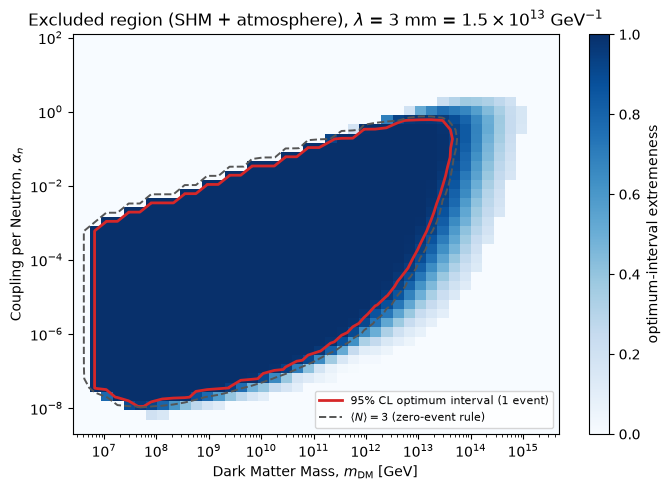

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
mesh = ax.pcolormesh(ms, alphas_n, extremeness, cmap="Blues",
                     vmin=0, vmax=1, shading="auto")
fig.colorbar(mesh, ax=ax, label="optimum-interval extremeness")
cs95 = ax.contour(ms, alphas_n, extremeness, levels=[CONFIDENCE],
                  colors="#d62728", linewidths=2)
cs3 = ax.contour(ms, alphas_n, counts, levels=[3.0], colors="#555555",
                 linewidths=1.4, linestyles="--")
ax.plot([], [], color="#d62728", lw=2,
        label=f"{CONFIDENCE:.0%} CL optimum interval ({EVENTS.size} event)")
ax.plot([], [], color="#555555", lw=1.4, ls="--",
        label=r"$\langle N\rangle = 3$ (zero-event rule)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV]")
ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
ax.set_title("Excluded region (SHM + atmosphere), " + lamb_label(LAMB))
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig("limit_contour.png", dpi=140)

### The contour with and without the flux constraint

Two versions of "at least one particle must pass by":

- **In-model $N_t \ge 1$**, with the reach $b_\text{max}(\alpha, v)$ from the
  impulse formula. This *cannot* move the boundary: $\mu \le N_t$ identically,
  because every above-threshold kick is a transit within $b_\text{max}$, and
  the 95% region already demands $\mu \gtrsim 3$. The overlay verifies the
  null: the contours coincide.
- **Capped-reach (physical) endpoint.** $N_t$ itself inherits the coupling —
  $b_\text{max} \propto \alpha$ for a long-range force — so raising $\alpha$
  inflates the countable area, not just the rate. Capping the reach at the
  apparatus / common-mode scale $b_\text{cap}$ makes the flux quantization
  coupling-independent:
  $N_t^\text{cap} \le (\rho/m)\,\bar v\,\pi b_\text{cap}^2\,T$, a hard
  Poisson wall at $m_\text{end} = \rho\,\bar v\,\pi b_\text{cap}^2\,T
  \approx 2.5\times10^{15}\ \text{GeV} \times (b_\text{cap}/10\,\text{cm})^2
  (T/2\,\text{wk})$, beyond which no coupling produces even one expected
  flyby. It truncates the massless band; the finite-range island is untouched
  (its own reach cap, $\sim\lambda K_1^{-1} \approx 7$ cm, is stronger, and its
  pinch at $3\times10^{13}$ sits far below $m_\text{end}$).


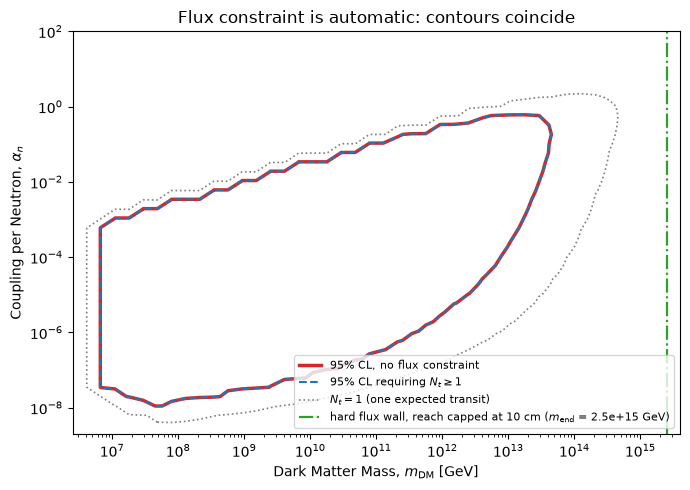

In [8]:
if N_T is not None:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.contour(ms, alphas_n, extremeness, levels=[CONFIDENCE],
               colors="#d62728", linewidths=2.5)
    masked = np.where(N_T >= 1.0, extremeness, 0.0)
    ax.contour(ms, alphas_n, masked, levels=[CONFIDENCE],
               colors="#1f77b4", linewidths=1.5, linestyles="--")
    ax.contour(ms, alphas_n, N_T, levels=[1.0], colors="#7f7f7f",
               linewidths=1.2, linestyles=":")
    ax.plot([], [], color="#d62728", lw=2.5, label="95% CL, no flux constraint")
    ax.plot([], [], color="#1f77b4", lw=1.5, ls="--",
            label=r"95% CL requiring $N_t \geq 1$")
    ax.plot([], [], color="#7f7f7f", lw=1.2, ls=":",
            label=r"$N_t = 1$ (one expected transit)")
    b_cap = 0.10  # apparatus / common-mode scale [m]
    m_end = 0.3 * 1e6 * 220e3 * np.pi * b_cap**2 * T_TOTAL
    ax.axvline(m_end, color="#2ca02c", lw=1.6, ls="-.")
    ax.plot([], [], color="#2ca02c", lw=1.6, ls="-.",
            label=rf"hard flux wall, reach capped at {b_cap*100:.0f} cm "
                  rf"($m_{{\rm end}}$ = {m_end:.1e} GeV)")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV]")
    ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
    ax.set_title("Flux constraint is automatic: contours coincide")
    ax.legend(loc="lower right", fontsize=8)
    fig.tight_layout()
    fig.savefig("limit_contour_flux.png", dpi=140)
else:
    print("n_transit not in scan file; rerun scripts/scan_grid.py")

### Transit-count map up to the Planck mass

**Top row:** color is $\log_{10} N_t$, the expected number of particles passing
within $\pi b_\text{max}^2$ during the exposure (halo flux, no attenuation —
the atmosphere only matters near the low-mass ceiling). White solid: $N_t = 1$;
white dashed: $N_t = 3$; red: the 95% exclusion contour from the scan.

The two panels make the mediator-range physics visible. For the **3 mm
mediator** the reach saturates ($b_\text{max} \le \lambda K_1^{-1}$), so the
$N_t = 1$ boundary becomes a near-vertical wall — beyond it no coupling
produces even one expected flyby, the "no cheating with $\alpha$" endpoint.
For the **massless** mediator the reach grows $\propto \alpha$, so the
boundary is a $\sqrt{m}$ diagonal that continues all the way to the Planck
mass: flux quantization alone never closes the band, only reach-capping
physics (apparatus scale) or external constraints do.

**Bottom row:** the flux-averaged threshold reach
$b_\text{max} = \sqrt{\langle b^2 \rangle}$ in meters, with contours at
everyday length scales. This is the aperture that converts flux into transits,
$N_t = \Phi \cdot \pi b_\text{max}^2 \cdot T$, and it answers "how can there
be transits at the Planck mass when the flux is only
$\sim 0.2\,/\mathrm{m}^2/\mathrm{yr}$": for the massless mediator the *formal*
reach at large coupling is macroscopic — $b_\text{max} = 2\alpha/(q_\text{th}
v) \sim 10$ km at $\alpha_n = 1$, an aperture of $\sim 10^9\,\mathrm{m}^2$ —
so even $7 \times 10^{-3}$ per m$^2$ per exposure yields $N_t \sim 10^6$. The
finite-range reach saturates at $\lambda K_1^{-1} \sim$ cm, which is why its
$N_t = 1$ wall is real. Of course a 10 km "reach" is not an apparatus: capping
it at a laboratory scale is exactly the hard flux wall shown earlier.


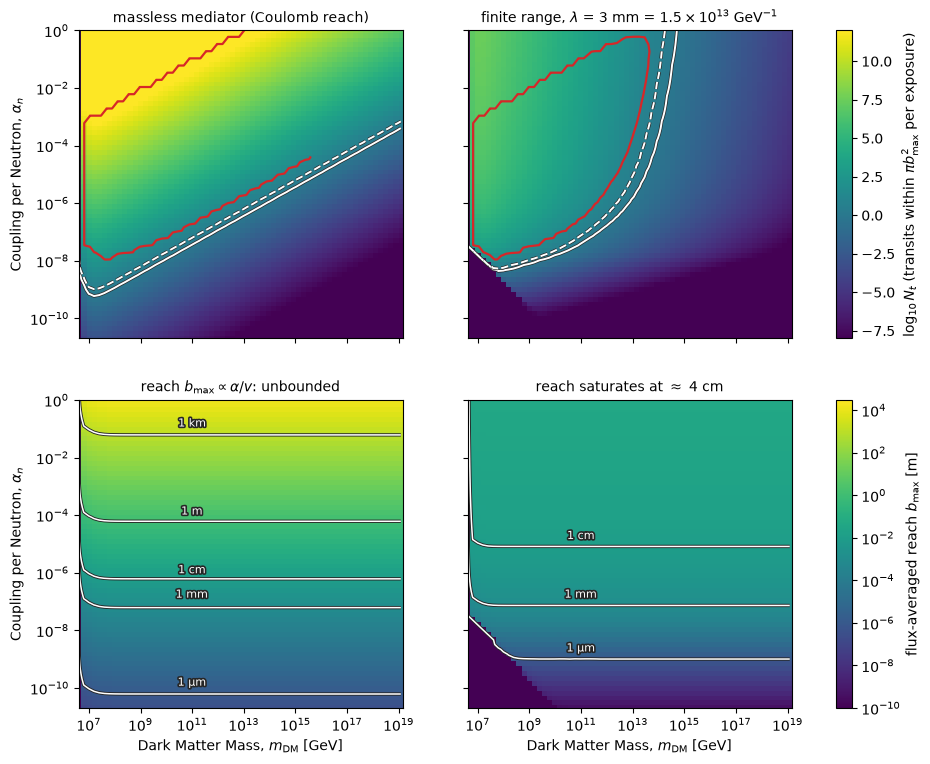

In [9]:
HBAR_C_M = 1.9733e-16  # GeV^-1 in meters

def transit_count_halo(m, alpha_n, lamb=None):
    # (N_t, flux-averaged pi*b_max^2 [m^2]) for the unattenuated halo flux;
    # lamb=None -> massless (analytic Coulomb reach)
    vs = np.geomspace(max(Q_THRESH / m, 1e-8), config.VESC, 200)
    if vs.size < 2 or vs[0] >= config.VESC:
        return 0.0, 0.0
    alpha = alpha_n * config.N_NEUTRONS
    if lamb is None:
        b = 2 * alpha / (Q_THRESH * vs) * HBAR_C_M
    else:
        b = cross_section.impact_parameter_max(Q_THRESH, alpha, lamb, R_eff, vs)
    flux_w = halo.standard_halo_model(vs) * (vs * units.C_M_S)
    area = np.pi * b**2
    n_m3 = 0.3 / m * 1e6
    nt = T_TOTAL * n_m3 * np.trapezoid(flux_w * area, vs)
    a_eff = np.trapezoid(flux_w * area, vs) / np.trapezoid(flux_w, vs)
    return nt, a_eff

M_PL = 1.22e19
ms_map = np.geomspace(4e6, M_PL, 64)
al_map = np.geomspace(2e-11, 1.0, 64)

def grids(lamb):
    out = np.array([[transit_count_halo(m, a, lamb) for m in ms_map]
                    for a in al_map])
    return out[:, :, 0], out[:, :, 1]

NT_ML_MAP, AEFF_ML_MAP = grids(None)
NT_FR_MAP, AEFF_FR_MAP = grids(LAMB)
B_ML_MAP = np.sqrt(AEFF_ML_MAP / np.pi)  # flux-averaged reach [m]
B_FR_MAP = np.sqrt(AEFF_FR_MAP / np.pi)

import matplotlib.patheffects as pe
from matplotlib.colors import LogNorm, Normalize

def outline(artists):  # keep white lines/labels legible on any viridis shade
    for a in artists:
        a.set_path_effects([pe.Stroke(linewidth=2.4, foreground="0.15"),
                            pe.Normal()])

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.8), sharex=True, sharey=True)
norm_nt = Normalize(vmin=-8, vmax=12)
norm_b = LogNorm(vmin=1e-10, vmax=3e4)
B_LEVELS = [1e-6, 1e-3, 1e-2, 1.0, 1e3]
B_NAMES = {1e-6: "1 µm", 1e-3: "1 mm", 1e-2: "1 cm", 1.0: "1 m", 1e3: "1 km"}
titles = ["massless mediator (Coulomb reach)", "finite range, " + lamb_label(LAMB)]

for j, (NT_MAP, B_MAP) in enumerate([(NT_ML_MAP, B_ML_MAP),
                                     (NT_FR_MAP, B_FR_MAP)]):
    ax = axes[0, j]
    z = np.log10(np.clip(NT_MAP, 1e-8, 1e12))
    mesh_nt = ax.pcolormesh(ms_map, al_map, z, cmap="viridis", norm=norm_nt,
                            shading="auto")
    for lev, ls in [(1.0, "-"), (3.0, "--")]:
        cs = ax.contour(ms_map, al_map, NT_MAP, levels=[lev], colors="w",
                        linewidths=1.4, linestyles=ls)
        outline(getattr(cs, "collections", [cs]))
    ax.set_title(titles[j], fontsize=10)

    ax = axes[1, j]
    mesh_b = ax.pcolormesh(ms_map, al_map, np.clip(B_MAP, 1e-10, None),
                           cmap="viridis", norm=norm_b, shading="auto")
    cs = ax.contour(ms_map, al_map, B_MAP, levels=B_LEVELS, colors="w",
                    linewidths=1.1)
    outline(getattr(cs, "collections", [cs]))
    # label each level just above its line, mid-plot (the lines are
    # horizontal away from the kinematic floor)
    col = np.argmin(np.abs(ms_map - 1e11))
    for lev in cs.levels:
        miss = np.abs(np.log10(B_MAP[:, col] / lev))
        if miss.min() < 0.3:
            y = al_map[miss.argmin()]
            txt = ax.text(1e11, y * 1.5, B_NAMES[lev], fontsize=8, color="w",
                          ha="center", va="bottom")
            outline([txt])
    note = (r"reach $b_{\rm max} \propto \alpha/v$: unbounded" if j == 0 else
            r"reach saturates at $\approx$ "
            + f"{B_MAP.max() * 100:.0f} cm")
    ax.set_title(note, fontsize=10)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV]")

# overlay the 95% exclusion contours from the scans where available
axes[0, 1].contour(ms, alphas_n, extremeness, levels=[CONFIDENCE],
                   colors="#d62728", linewidths=1.6)
ML0 = Path("scan_results_massless.npz")
if ML0.exists():
    dml0 = np.load(ML0)
    axes[0, 0].contour(dml0["ms"], dml0["alphas_n"], dml0["extremeness"],
                       levels=[CONFIDENCE], colors="#d62728", linewidths=1.6)

for ax in axes[:, 0]:
    ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
axes[0, 0].set_ylim(al_map[0], 1.0)
fig.colorbar(mesh_nt, ax=axes[0, :], label=r"$\log_{10} N_t$ (transits within "
                                           r"$\pi b_{\rm max}^2$ per exposure)")
fig.colorbar(mesh_b, ax=axes[1, :],
             label=r"flux-averaged reach $b_{\rm max}$ [m]")
fig.savefig("flux_map.png", dpi=140, bbox_inches="tight")

## Massless-mediator limit ($\lambda \to \infty$)

As $\lambda \to \infty$: $G_2 \to 1$, $K_1(x) \to 1/x$, the impulse becomes
Coulomb-like $q(b) = 2\alpha/(bv)$, and the projected cross section collapses
to the closed form $d\sigma/dq = 2\pi\alpha^2/(v^2 q^3)$
(`cross_section_rutherford_projection`; the unprojected $|q|$ version carries
$8\pi$). The $1/q^3$ shape no longer depends on $\alpha_n$ — only the
atmosphere still couples the spectrum to the coupling. We first check that the
$K_1$ machinery converges to the closed form at $\lambda = 3$ m (effectively
massless for all detector scales; the atmospheric Coulomb logarithm stays
regulated at that $\lambda$), then compare islands using the companion scan
(`scripts/scan_grid.py --lamb 3.0`).

The contrast to expect: with no momentum-transfer cap, the massless reach in
impact parameter grows $\propto \alpha$ (not logarithmically), so the flux
pinch-off disappears — the extra reach always buys back the $1/m$ number
density, and the island becomes an open band marching up-and-right: floor
(statistics) and atmospheric ceiling both rise as $\sim\sqrt{m}$. The same
behavior appears in Monteiro et al., PRL 125, 181102 (arXiv:2007.12067): their
$m_\phi = 0$ limit rises with mass with no endpoint ("the limits become weaker
at large $M_X$ due to the reduced DM number density"), while their finite
$m_\phi$ curves collapse at high mass like our finite-range island. In-model
the band never closes; validity ends where the required impact parameters
exceed the apparatus scale and the differential-kick approximation breaks
($b_\text{max} \sim$ 10 cm at $10^{15}$ GeV, $\sim$ 1 m at $10^{17}$ GeV).


In [10]:
# validate: K1 machinery at lambda = 3 m vs the analytic Coulomb projection.
# Coulomb regime requires b << lambda, i.e. q_tilde >> 1: pick a small coupling
# so threshold kicks come from close flybys.
LAMB_ML = 3.0
interp_ml = cross_section.make_dsigma_dq_interpolant(1e-25, R_eff, LAMB_ML,
                                                     N_points=600)
alpha_chk = 1e-6 * config.N_NEUTRONS
v_chk = 1e-3
qs_chk = np.geomspace(Q_THRESH, 10 * Q_THRESH, 6)
q_tilde_chk = cross_section.q_tilde_map(qs_chk, alpha_chk, LAMB_ML, R_eff, v_chk)
num = cross_section.dsigma_dq(qs_chk, alpha_chk, LAMB_ML, R_eff, v_chk, interp_ml)
ana = cross_section.cross_section_rutherford_projection(qs_chk, alpha_chk, v_chk)
print(f"q_tilde range: {q_tilde_chk.min():.0f} .. {q_tilde_chk.max():.0f}")
print("K1 machinery / analytic (should be ~1):", np.round(num / ana, 4))

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 2/600 [00:00<00:31, 18.94it/s]

  1%|          | 4/600 [00:00<00:34, 17.04it/s]

  1%|          | 6/600 [00:00<00:33, 17.85it/s]

  1%|▏         | 8/600 [00:00<00:32, 18.33it/s]

...

 82%|████████▏ | 489/600 [00:15<00:01, 75.49it/s]

 83%|████████▎ | 497/600 [00:15<00:01, 73.09it/s]

 84%|████████▍ | 507/600 [00:16<00:01, 78.69it/s]

100%|██████████| 600/600 [00:16<00:00, 37.27it/s]

q_tilde range: 254 .. 2539
K1 machinery / analytic (should be ~1): [1.0111 1.0032 1.005  1.011  1.0146 1.0137]


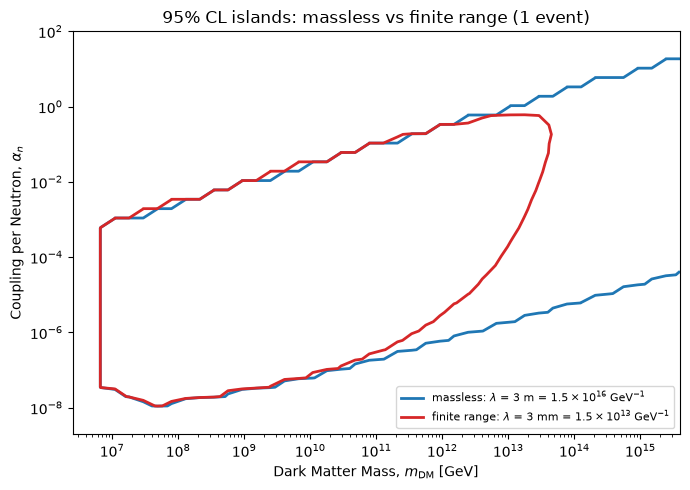

In [11]:
CS95_ML = None
ML = Path("scan_results_massless.npz")
if ML.exists():
    dml = np.load(ML)
    assert np.allclose(dml["events"], EVENTS)
    fig, ax = plt.subplots(figsize=(7, 5))
    CS95_ML = ax.contour(dml["ms"], dml["alphas_n"], dml["extremeness"],
                         levels=[CONFIDENCE], colors="#1f77b4", linewidths=2)
    ax.contour(ms, alphas_n, extremeness, levels=[CONFIDENCE],
               colors="#d62728", linewidths=2)
    ax.plot([], [], color="#1f77b4", lw=2,
            label="massless: " + lamb_label(float(dml["lamb"])))
    ax.plot([], [], color="#d62728", lw=2,
            label="finite range: " + lamb_label(LAMB))
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV]")
    ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
    ax.set_title(f"{CONFIDENCE:.0%} CL islands: massless vs finite range "
                 f"({EVENTS.size} event)")
    ax.legend(loc="lower right", fontsize=8)
    fig.tight_layout()
    fig.savefig("limit_contour_compare.png", dpi=140)
else:
    print("scan_results_massless.npz not found; "
          "run scripts/scan_grid.py --lamb 3.0")

## Machine-readable output

Everything on the plot, written to `limit_contour_data.npz` so nobody ever
has to digitize the figure: axis grids, both 2D surfaces, the event list,
and the contour lines as NaN-separated (m, alpha_n) polylines.


In [12]:
def contour_polyline(cs):
    # all segments of a single-level contour as one NaN-separated (N, 2) array
    parts = []
    for seg in cs.allsegs[0]:
        parts.append(seg)
        parts.append(np.full((1, 2), np.nan))
    return np.vstack(parts) if parts else np.empty((0, 2))


extra = {}
if CS95_ML is not None:
    extra["contour_95_massless"] = contour_polyline(CS95_ML)
if N_T is not None:
    extra["n_transit"] = N_T
extra["nt_map_ms"] = ms_map
extra["nt_map_alphas"] = al_map
extra["nt_map_massless"] = NT_ML_MAP
extra["nt_map_finite"] = NT_FR_MAP
extra["nt_map_area_massless"] = AEFF_ML_MAP
extra["nt_map_area_finite"] = AEFF_FR_MAP
np.savez(
    "limit_contour_data.npz",
    ms=ms,                              # mass grid [GeV]
    alphas_n=alphas_n,                  # coupling grid
    extremeness=extremeness,            # optimum-interval extremeness surface
    counts=counts,                      # expected-event surface mu(m, alpha)
    events=EVENTS,                      # observed kicks [GeV]
    contour_95=contour_polyline(cs95),  # 95% CL line, columns (m, alpha_n)
    contour_n3=contour_polyline(cs3),   # <N>=3 line, columns (m, alpha_n)
    lamb=LAMB, t_total=T_TOTAL, confidence=CONFIDENCE,
    **extra,
)
d = np.load("limit_contour_data.npz")
print("limit_contour_data.npz:", {k: d[k].shape for k in d.files})

limit_contour_data.npz: {'ms': (44,), 'alphas_n': (44,), 'extremeness': (44, 44), 'counts': (44, 44), 'events': (1,), 'contour_95': (130, 2), 'contour_n3': (132, 2), 'lamb': (), 't_total': (), 'confidence': (), 'contour_95_massless': (138, 2), 'n_transit': (44, 44), 'nt_map_ms': (64,), 'nt_map_alphas': (64,), 'nt_map_massless': (64, 64), 'nt_map_finite': (64, 64), 'nt_map_area_massless': (64, 64), 'nt_map_area_finite': (64, 64)}


## Flux validity: $b_\text{max}$ and expected transits

The reach of a flyby is computable in closed form:
$b_\text{max} = \lambda\,K_1^{-1}\!\big(q_\text{th}\lambda v/2\alpha G_2\big)$
(`cross_section.impact_parameter_max`), tending to the Coulomb
$b_\text{max} = 2\alpha G_2/(q_\text{th} v)$ as $\lambda\to\infty$ and to zero at
the momentum-transfer cap. A sanity requirement is that wherever we claim
exclusion, at least one particle is *expected* to pass within reach during the
exposure. This is automatic: every above-threshold kick comes from a transit
with $b < b_\text{max}$, so the expected transit count
$N_t = T\int n\,f(v)\,v\,\pi b_\text{max}^2(v)\,dv$ satisfies
$N_t \ge \mu$ (the projection onto the sensitive axis only removes kicks),
and the 95% contour already requires $\mu \gtrsim 3$. The table verifies this
along the finite-range exclusion boundary; $b_\text{max}$ also quantifies
where the pointlike-sensor model is safe (reach $\ll$ apparatus scale).


In [13]:
C_M_S = 299792458.0
poly = contour_polyline(cs95)
pts = poly[~np.isnan(poly).any(axis=1)]
idx = np.linspace(0, len(pts) - 1, 10).astype(int)

print(f"{'m [GeV]':>10} {'alpha_n':>9} {'max b_max [cm]':>14} {'N_transit':>10} {'mu':>7}")
for m, a in pts[idx]:
    v_min = Q_THRESH / m / 10
    v_f_samples = atmosphere.compute_v_f_distribution(
        a, LAMB, m, v_i_samples, v_min=v_min, n_grid=80)
    f_v_f = atmosphere.compute_f_vf(v_f_samples, v_min)[0]
    alpha = a * config.N_NEUTRONS
    vs = np.geomspace(max(Q_THRESH / m, 1e-8), config.VESC, 300)
    b = cross_section.impact_parameter_max(Q_THRESH, alpha, LAMB, R_eff, vs)
    n_transit = expected_transits(a, m, f_v_f)
    qs = np.geomspace(Q_THRESH, 1e4 * Q_THRESH, 200)
    rate = differential_rate_trapz(qs, a, LAMB, m, R_eff, f_v_f, interpolant)
    mu = np.trapezoid(rate, qs) * T_TOTAL
    print(f"{m:>10.2e} {a:>9.1e} {b.max() * 100:>14.2f} {n_transit:>10.1f} {mu:>7.2f}")
print("\nN_transit >= mu everywhere: exclusion is never claimed where fewer "
      "than ~3 particles are expected within reach.")

   m [GeV]   alpha_n max b_max [cm]  N_transit      mu


  4.83e+07   1.1e-08           0.07       55.2    3.43


  8.58e+09   6.2e-08           1.50       24.8    5.57


  5.61e+11   1.6e-06           3.58       18.0    5.98


  9.73e+12   1.9e-04           5.09        9.7    3.99


...

  3.43e+11   1.9e-01           6.85       42.1   16.68


  2.49e+09   1.9e-02           4.74      949.1  184.01


  2.89e+07   1.9e-03           2.79    37313.5 3662.32


  6.60e+06   3.4e-06           0.69   341255.7 11047.26


  4.83e+07   1.1e-08           0.07       55.2    3.43

N_transit >= mu everywhere: exclusion is never claimed where fewer than ~3 particles are expected within reach.


## Notes

- **Data**: replace `EVENTS` and rerun. More candidates only move the
  extremeness surface; the machinery is untouched.
- **Physics tweaks** happen in this notebook: the `differential_rate_trapz`
  formula, the halo/attenuation calls, `LAMB`, the grids, `T_TOTAL`.
- **Knobs**: `n_grid` (attenuation ODE resolution — the runtime driver),
  `n_mc` / `mu_dex` in `limits.extremeness_and_mu`, and the grid densities.
- `limit_contour_data.npz` is the plottable record of this figure;
  `scan_results.npz` (from `scripts/scan_grid.py`) is the raw scan.
- With zero events the extremeness contour coincides with
  $\langle N\rangle \simeq 3$ at 95% CL by construction, so the old rule is
  recovered exactly in the background-free case.
